In [ ]:
from pathlib import Path
from collections import defaultdict

DRIVE_OUT = Path("/content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/training_final")

MONTH_NAMES = {1:"Oca",2:"Şub",3:"Mar",4:"Nis",5:"May",6:"Haz",
               7:"Tem",8:"Ağu",9:"Eyl",10:"Eki",11:"Kas",12:"Ara"}

CLASSES = ["normal","trespassing","loitering","object_abandonment"]

def is_winter(day): return 202101 <= int(day[:6]) <= 202103

# ── Tüm veriyi tara ───────────────────────────────────────────────────────────
stats = defaultdict(lambda: defaultdict(lambda: {
    "clips":0, "frames":0,
    "months": defaultdict(int),
    "days": set(),
    "winter":0, "summer":0,
}))

for split in ["train","test"]:
    for cls in CLASSES:
        cls_dir = DRIVE_OUT / split / cls
        if not cls_dir.exists():
            continue
        for day_dir in sorted(cls_dir.iterdir()):
            if not day_dir.is_dir(): continue
            clips = [c for c in day_dir.iterdir() if c.is_dir()]
            for clip in clips:
                frames = len(list(clip.glob("*.jpg")))
                month  = int(day_dir.name[4:6])
                season = "winter" if is_winter(day_dir.name) else "summer"
                s      = stats[split][cls]
                s["clips"]          += 1
                s["frames"]         += frames
                s["months"][month]  += 1
                s["days"].add(day_dir.name)
                s[season]           += 1

# ── ANA TABLO ─────────────────────────────────────────────────────────────────
print("="*75)
print("  CNN VERİSETİ TAM ANALİZ RAPORU")
print("="*75)

# Genel özet
print(f"\n{'Sınıf':<22} {'Train':>8} {'Test':>8} {'Toplam':>8} "
      f"{'Kış':>6} {'Yaz':>6} {'Gün':>6}")
print("─"*75)

grand_train = grand_test = 0
for cls in CLASSES:
    tr = stats["train"][cls]["clips"]
    te = stats["test"][cls]["clips"]
    w  = stats["train"][cls]["winter"] + stats["test"][cls]["winter"]
    s  = stats["train"][cls]["summer"] + stats["test"][cls]["summer"]
    d  = len(stats["train"][cls]["days"] | stats["test"][cls]["days"])
    grand_train += tr
    grand_test  += te
    print(f"  {cls:<20} {tr:>8} {te:>8} {tr+te:>8} {w:>6} {s:>6} {d:>6}")

print("─"*75)
print(f"  {'TOPLAM':<20} {grand_train:>8} {grand_test:>8} "
      f"{grand_train+grand_test:>8}")

# ── AY BAZLI DAĞILIM ──────────────────────────────────────────────────────────
print(f"\n{'='*75}")
print("  AY BAZLI DAĞILIM (Train + Test)")
print(f"{'='*75}")

header = f"  {'Ay':<6}" + "".join(f"{c[:10]:>14}" for c in CLASSES) + f"{'TOPLAM':>10}"
print(header)
print("  " + "─"*70)

month_totals = defaultdict(int)
for month in range(1,13):
    row_vals = []
    row_total = 0
    has_data  = False
    for cls in CLASSES:
        tr = stats["train"][cls]["months"][month]
        te = stats["test"][cls]["months"][month]
        val = tr + te
        row_vals.append(val)
        row_total += val
        if val > 0: has_data = True
    if has_data:
        row = f"  {MONTH_NAMES[month]:<6}"
        for v in row_vals:
            row += f"{v:>14}"
        row += f"{row_total:>10}"
        print(row)
        month_totals[month] = row_total

# ── SPLIT BAZLI DETAY ─────────────────────────────────────────────────────────
for split in ["train","test"]:
    print(f"\n{'='*75}")
    print(f"  [{split.upper()}] DETAY")
    print(f"{'='*75}")
    print(f"  {'Sınıf':<22} {'Klip':>6} {'Frame':>8} "
          f"{'Kış':>6} {'Yaz':>6} {'Gün':>6}")
    print("  " + "─"*55)
    for cls in CLASSES:
        s  = stats[split][cls]
        tr = s["clips"]
        if tr == 0: continue
        print(f"  {cls:<22} {tr:>6} {s['frames']:>8} "
              f"{s['winter']:>6} {s['summer']:>6} "
              f"{len(s['days']):>6}")

# ── MEVSİM ÖZET ───────────────────────────────────────────────────────────────
print(f"\n{'='*75}")
print("  MEVSİM ÖZET (Train + Test)")
print(f"{'='*75}")
print(f"  {'Sınıf':<22} {'Kış':>8} {'Yaz':>8} {'Oran K/Y':>12}")
print("  " + "─"*55)
for cls in CLASSES:
    w = stats["train"][cls]["winter"] + stats["test"][cls]["winter"]
    s = stats["train"][cls]["summer"] + stats["test"][cls]["summer"]
    total = w + s
    if total == 0: continue
    ratio = f"{w/total*100:.0f}%/{s/total*100:.0f}%"
    print(f"  {cls:<22} {w:>8} {s:>8} {ratio:>12}")

# ── GÜN ÇAKIŞMA KONTROLİ ─────────────────────────────────────────────────────
print(f"\n{'='*75}")
print("  GÜN ÇAKIŞMA KONTROLÜ")
print(f"{'='*75}")
for cls in CLASSES:
    train_days = stats["train"][cls]["days"]
    test_days  = stats["test"][cls]["days"]
    overlap    = train_days & test_days
    status     = "YOK ✓" if not overlap else f"VAR! {overlap}"
    print(f"  {cls:<22} train:{len(train_days):>3} gün  "
          f"test:{len(test_days):>3} gün  çakışma:{status}")

print(f"\n{'='*75}")
total_clips = grand_train + grand_test
print(f"  GENEL TOPLAM: {total_clips} klip  "
      f"({grand_train} train + {grand_test} test)")
print(f"{'='*75}")

  CNN VERİSETİ TAM ANALİZ RAPORU

Sınıf                     Train     Test   Toplam    Kış    Yaz    Gün
───────────────────────────────────────────────────────────────────────────
  normal                    193       48      241    100    141    155
  trespassing               193       49      242     65    177     18
  loitering                 193       41      234     99    135     50
  object_abandonment        205       41      246    108    138     59
───────────────────────────────────────────────────────────────────────────
  TOPLAM                    784      179      963

  AY BAZLI DAĞILIM (Train + Test)
  Ay            normal    trespassin     loitering    object_aba    TOPLAM
  ──────────────────────────────────────────────────────────────────────
  Oca               42             0            19            26        87
  Şub               28             7            45            31       111
  Mar               30            58            35            51       174
 

In [ ]:
import cv2
import numpy as np
import random
import shutil
import time
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
from collections import defaultdict

random.seed(42)

DRIVE_OUT   = Path("/content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/training_final")
LOCAL_FINAL = Path("/content/training_final")

# ── Adım 1: Drive'daki test/trespassing'i locale'e kopyala ───────────────────
print("Test/trespassing Drive → Locale...")
src_dir = DRIVE_OUT / "test" / "trespassing"
dst_dir = LOCAL_FINAL / "test" / "trespassing"

files = list(src_dir.rglob("*.jpg"))
print(f"Drive'da {len(files)} frame bulundu")

def copy_file(args):
    src, dst = args
    dst.parent.mkdir(parents=True, exist_ok=True)
    if not dst.exists():
        shutil.copy2(str(src), str(dst))
    return str(dst)

jobs = [(f, dst_dir / f.relative_to(src_dir)) for f in files]
with ThreadPoolExecutor(max_workers=64) as ex:
    list(tqdm(ex.map(lambda a: copy_file(a), jobs),
              total=len(jobs), desc="Kopyalanıyor"))

# Kontrol
test_tres_clips = [d for d in dst_dir.rglob("frame_001.jpg")]
print(f"✓ Locale test/trespassing: {len(test_tres_clips)} klip")

# ── Augmentation fonksiyonları ────────────────────────────────────────────────
def read_frames(clip_dir):
    frames = []
    for f in sorted(clip_dir.glob("*.jpg")):
        img = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            frames.append(img)
    return frames

def aug_flip(frames):
    return [cv2.flip(f, 1) for f in frames]

def aug_noise(frames, std=None):
    std = std or random.uniform(0.01, 0.05)
    result = []
    for f in frames:
        noise = np.random.normal(0, std*255, f.shape).astype(np.float32)
        result.append(np.clip(f.astype(np.float32)+noise, 0, 255).astype(np.uint8))
    return result

def aug_brightness(frames, shift=None):
    shift = shift or random.uniform(-0.25, 0.25)*255
    return [np.clip(f.astype(np.float32)+shift, 0, 255).astype(np.uint8)
            for f in frames]

def aug_temporal_jitter(frames, jitter=None):
    if len(frames) < 16:
        return frames
    jitter = jitter or random.randint(1, min(4, len(frames)-16)) if len(frames) > 16 else 0
    start  = min(jitter, len(frames)-16)
    return frames[start:start+16]

def apply_tres_aug(frames, combo_id):
    """8 farklı trespassing kombinasyonu."""
    f = [x.copy() for x in frames]
    combos = [
        lambda x: aug_noise(aug_flip(x)),
        lambda x: aug_brightness(aug_noise(x)),
        lambda x: aug_flip(aug_brightness(x)),
        lambda x: aug_noise(aug_brightness(aug_flip(x))),
        lambda x: aug_brightness(x, shift=random.uniform(30,60)),
        lambda x: aug_noise(x, std=random.uniform(0.03,0.06)),
        lambda x: aug_flip(aug_noise(aug_brightness(x))),
        lambda x: aug_brightness(aug_flip(x), shift=random.uniform(-60,-30)),
    ]
    return combos[combo_id % 8](f)

def write_clip(frames, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)
    for i, frame in enumerate(frames):
        cv2.imwrite(str(out_dir/f"frame_{i+1:03d}.jpg"),
                    frame, [cv2.IMWRITE_JPEG_QUALITY, 95])

# ── Adım 2: Train trespassing 213 → 260 (+47) ────────────────────────────────
print("\nTrain trespassing augmentation (213 → 260)...")

train_tres_dir  = LOCAL_FINAL / "train" / "trespassing"
train_clip_dirs = []
for day_dir in sorted(train_tres_dir.iterdir()):
    if not day_dir.is_dir(): continue
    for clip_dir in sorted(day_dir.iterdir()):
        if not clip_dir.is_dir(): continue
        if not clip_dir.name.startswith("aug_"):  # sadece orijinaller
            train_clip_dirs.append((day_dir.name, clip_dir))

print(f"Orijinal train klip: {len(train_clip_dirs)}")

NEED_TRAIN = 260 - 213  # 47 klip

# Yaz/kış dengeli seç
winter_clips = [(d,c) for d,c in train_clip_dirs if 202101<=int(d[:6])<=202103]
summer_clips = [(d,c) for d,c in train_clip_dirs if not (202101<=int(d[:6])<=202103)]

# Round-robin yaz/kış
source_pool = []
wi, si = 0, 0
while len(source_pool) < NEED_TRAIN * 2:
    if winter_clips:
        source_pool.append(winter_clips[wi % len(winter_clips)])
        wi += 1
    if summer_clips:
        source_pool.append(summer_clips[si % len(summer_clips)])
        si += 1
    if len(source_pool) >= NEED_TRAIN * 2:
        break

random.shuffle(source_pool)
source_pool = source_pool[:NEED_TRAIN]

train_aug_jobs = []
for i, (day, clip_dir) in enumerate(source_pool):
    frames = read_frames(clip_dir)
    if not frames: continue
    if random.random() > 0.5:
        frames = aug_temporal_jitter(frames)
    aug_frames = apply_tres_aug(frames, combo_id=i)
    out_dir = train_tres_dir / day / f"aug_{i:04d}_{clip_dir.name}"
    train_aug_jobs.append((aug_frames, out_dir))

for frames, out_dir in tqdm(train_aug_jobs, desc="Train aug yazılıyor"):
    write_clip(frames, out_dir)

# Kontrol
new_train = len(list(train_tres_dir.rglob("frame_001.jpg")))
print(f"✓ Train trespassing: {new_train}")

# ── Adım 3: Test trespassing 49 → 85 (+36) ───────────────────────────────────
print("\nTest trespassing augmentation (49 → 85)...")

test_tres_dir  = LOCAL_FINAL / "test" / "trespassing"
test_clip_dirs = []
for day_dir in sorted(test_tres_dir.iterdir()):
    if not day_dir.is_dir(): continue
    for clip_dir in sorted(day_dir.iterdir()):
        if not clip_dir.is_dir(): continue
        if not clip_dir.name.startswith("aug_"):
            test_clip_dirs.append((day_dir.name, clip_dir))

print(f"Orijinal test klip: {len(test_clip_dirs)}")

NEED_TEST = 85 - 49  # 36 klip

# Yaz/kış dengeli
winter_t = [(d,c) for d,c in test_clip_dirs if 202101<=int(d[:6])<=202103]
summer_t = [(d,c) for d,c in test_clip_dirs if not (202101<=int(d[:6])<=202103)]

source_test = []
wi, si = 0, 0
while len(source_test) < NEED_TEST * 2:
    if winter_t:
        source_test.append(winter_t[wi % len(winter_t)])
        wi += 1
    if summer_t:
        source_test.append(summer_t[si % len(summer_t)])
        si += 1
    if len(source_test) >= NEED_TEST * 2:
        break

random.shuffle(source_test)
source_test = source_test[:NEED_TEST]

test_aug_jobs = []
for i, (day, clip_dir) in enumerate(source_test):
    frames = read_frames(clip_dir)
    if not frames: continue
    if random.random() > 0.5:
        frames = aug_temporal_jitter(frames)
    aug_frames = apply_tres_aug(frames, combo_id=i+100)
    out_dir = test_tres_dir / day / f"aug_{i:04d}_{clip_dir.name}"
    test_aug_jobs.append((aug_frames, out_dir))

for frames, out_dir in tqdm(test_aug_jobs, desc="Test aug yazılıyor"):
    write_clip(frames, out_dir)

new_test = len(list(test_tres_dir.rglob("frame_001.jpg")))
print(f"✓ Test trespassing: {new_test}")

# ── Adım 4: Locale → Drive yaz ────────────────────────────────────────────────
print("\nDrive'a yazılıyor...")
new_files = []
for f in LOCAL_FINAL.rglob("*.jpg"):
    if "aug_" in f.parts[-2]:
        rel = f.relative_to(LOCAL_FINAL)
        dst = DRIVE_OUT / rel
        if not dst.exists():
            new_files.append((f, dst))

print(f"Yeni dosya: {len(new_files)}")
with ThreadPoolExecutor(max_workers=64) as ex:
    list(tqdm(ex.map(copy_file, new_files),
              total=len(new_files), desc="Drive'a yazılıyor"))

# ── Final özet ────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  FINAL ÖZET")
print("="*55)
print(f"  {'Sınıf':<22} {'Train':>8} {'Test':>8} {'Toplam':>8}")
print("  " + "─"*45)
for cls in ["normal","trespassing","loitering","object_abandonment"]:
    tr = len(list((LOCAL_FINAL/"train"/cls).rglob("frame_001.jpg"))) if (LOCAL_FINAL/"train"/cls).exists() else 0
    te = len(list((LOCAL_FINAL/"test"/cls).rglob("frame_001.jpg"))) if (LOCAL_FINAL/"test"/cls).exists() else 0
    print(f"  {cls:<22} {tr:>8} {te:>8} {tr+te:>8}")

Test/trespassing Drive → Locale...
Drive'da 576 frame bulundu


Kopyalanıyor: 100%|██████████| 576/576 [00:03<00:00, 148.51it/s]


✓ Locale test/trespassing: 36 klip

Train trespassing augmentation (213 → 260)...
Orijinal train klip: 159


Train aug yazılıyor: 100%|██████████| 47/47 [00:00<00:00, 121.16it/s]


✓ Train trespassing: 260

Test trespassing augmentation (49 → 85)...
Orijinal test klip: 36


Test aug yazılıyor: 100%|██████████| 36/36 [00:00<00:00, 92.68it/s]


✓ Test trespassing: 72

Drive'a yazılıyor...
Yeni dosya: 1200


Drive'a yazılıyor: 100%|██████████| 1200/1200 [00:08<00:00, 146.89it/s]



  FINAL ÖZET
  Sınıf                     Train     Test   Toplam
  ─────────────────────────────────────────────
  normal                      273       88      361
  trespassing                 260       72      332
  loitering                   273       81      354
  object_abandonment          285       81      366


In [ ]:
import cv2
import numpy as np
import random
import shutil
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import defaultdict
from tqdm import tqdm

random.seed(42)

LOCAL_FINAL = Path("/content/training_final")
DRIVE_OUT   = Path("/content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/training_final")

def is_winter(day): return 202101 <= int(day[:6]) <= 202103

# ── Augmentation fonksiyonları (flip YOK) ────────────────────────────────────
def aug_noise(frames, std=None):
    std = std or random.uniform(0.01, 0.05)
    return [np.clip(f.astype(np.float32) +
                    np.random.normal(0, std*255, f.shape),
                    0, 255).astype(np.uint8) for f in frames]

def aug_brightness(frames, shift=None):
    shift = shift or random.uniform(-0.25, 0.25)*255
    return [np.clip(f.astype(np.float32)+shift,
                    0, 255).astype(np.uint8) for f in frames]

def aug_contrast(frames, alpha=None):
    alpha = alpha or random.uniform(0.7, 1.3)
    return [np.clip(f.astype(np.float32)*alpha,
                    0, 255).astype(np.uint8) for f in frames]

def aug_blur(frames):
    return [cv2.GaussianBlur(f, (3,3), 0) for f in frames]

def aug_temporal_jitter(frames):
    if len(frames) <= 16: return frames
    jitter = random.randint(1, min(4, len(frames)-16))
    return frames[jitter:jitter+16]

def apply_tres_aug(frames, combo_id):
    """8 combo — flip YOK."""
    f = [x.copy() for x in frames]
    combos = [
        lambda x: aug_noise(x),
        lambda x: aug_brightness(x),
        lambda x: aug_noise(aug_brightness(x)),
        lambda x: aug_brightness(x, shift=random.uniform(30,70)),
        lambda x: aug_noise(x, std=random.uniform(0.03,0.06)),
        lambda x: aug_contrast(aug_noise(x)),
        lambda x: aug_blur(aug_noise(x)),
        lambda x: aug_brightness(x, shift=random.uniform(-70,-30)),
    ]
    return combos[combo_id % 8](f)

def read_frames(clip_dir):
    frames = []
    for f in sorted(clip_dir.glob("*.jpg")):
        img = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            frames.append(img)
    return frames

def write_clip(frames, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)
    for i, frame in enumerate(frames):
        cv2.imwrite(str(out_dir/f"frame_{i+1:03d}.jpg"),
                    frame, [cv2.IMWRITE_JPEG_QUALITY, 95])

def copy_to_drive(local_clip, drive_base, local_base):
    rel      = local_clip.relative_to(local_base)
    dst_dir  = drive_base / rel
    dst_dir.mkdir(parents=True, exist_ok=True)
    for f in sorted(local_clip.glob("*.jpg")):
        dst = dst_dir / f.name
        if not dst.exists():
            shutil.copy2(str(f), str(dst))

# ── Orijinal klipleri tara ────────────────────────────────────────────────────
def get_orig_clips(split):
    tres = LOCAL_FINAL / split / "trespassing"
    clips = []
    for day_dir in sorted(tres.iterdir()):
        if not day_dir.is_dir(): continue
        for clip_dir in sorted(day_dir.iterdir()):
            if not clip_dir.is_dir(): continue
            if not clip_dir.name.startswith("aug_"):
                clips.append({
                    "day":      day_dir.name,
                    "clip_dir": clip_dir,
                    "season":   "KIŞ" if is_winter(day_dir.name) else "YAZ",
                })
    return clips

train_orig = get_orig_clips("train")
test_orig  = get_orig_clips("test")

# Mevcut aug sayıları
def count_clips(split):
    tres = LOCAL_FINAL / split / "trespassing"
    orig = aug = 0
    for day_dir in tres.iterdir():
        if not day_dir.is_dir(): continue
        for clip_dir in day_dir.iterdir():
            if not clip_dir.is_dir(): continue
            if clip_dir.name.startswith("aug_"): aug += 1
            else: orig += 1
    return orig, aug

tr_orig, tr_aug = count_clips("train")
te_orig, te_aug = count_clips("test")

print(f"Train: orijinal={tr_orig}  mevcut_aug={tr_aug}  toplam={tr_orig+tr_aug}")
print(f"Test:  orijinal={te_orig}  mevcut_aug={te_aug}  toplam={te_orig+te_aug}")

NEED_TRAIN = max(0, 250 - (tr_orig + tr_aug))
NEED_TEST  = max(0, 70  - (te_orig + te_aug))
print(f"\nEklenecek train aug: {NEED_TRAIN}")
print(f"Eklenecek test aug : {NEED_TEST}")

# ── Yaz/kış dengeli kaynak seç ────────────────────────────────────────────────
def balanced_source(clips, n):
    """Round-robin yaz/kış."""
    winter = [c for c in clips if c["season"]=="KIŞ"]
    summer = [c for c in clips if c["season"]=="YAZ"]
    pool   = []
    wi = si = 0
    while len(pool) < n * 3:
        if winter:
            pool.append(winter[wi % len(winter)]); wi += 1
        if summer:
            pool.append(summer[si % len(summer)]); si += 1
        if len(pool) >= n * 3: break
    random.shuffle(pool)
    return pool[:n]

# ── Augment + Locale yaz ──────────────────────────────────────────────────────
def augment_and_save(orig_clips, need, split, start_idx=0):
    if need <= 0:
        print(f"  {split}: ek augmentation gerekmez")
        return []
    source = balanced_source(orig_clips, need)
    saved  = []
    for i, clip_info in enumerate(tqdm(source, desc=f"{split} aug")):
        frames = read_frames(clip_info["clip_dir"])
        if not frames: continue

        # Temporal jitter %50
        if random.random() > 0.5:
            jittered = aug_temporal_jitter(frames)
            if len(jittered) == 16:
                frames = jittered

        aug_frames = apply_tres_aug(frames, combo_id=start_idx+i)
        idx        = start_idx + i
        out_name   = f"aug_{idx:04d}_{clip_info['clip_dir'].name}"
        out_dir    = (LOCAL_FINAL / split / "trespassing" /
                      clip_info["day"] / out_name)
        write_clip(aug_frames, out_dir)
        saved.append(out_dir)
    return saved

print("\nTrain augmentation...")
train_new = augment_and_save(train_orig, NEED_TRAIN, "train", start_idx=200)

print("Test augmentation...")
test_new  = augment_and_save(test_orig,  NEED_TEST,  "test",  start_idx=500)

# ── Locale → Drive ────────────────────────────────────────────────────────────
all_new = train_new + test_new
print(f"\nDrive'a yazılıyor ({len(all_new)} yeni klip)...")

with ThreadPoolExecutor(max_workers=32) as ex:
    futures = [ex.submit(copy_to_drive, c, DRIVE_OUT, LOCAL_FINAL)
               for c in all_new]
    for f in tqdm(as_completed(futures), total=len(all_new)):
        f.result()

# ── Final kontrol ─────────────────────────────────────────────────────────────
print("\n── Final ───────────────────────────────────────────────")
for split in ["train","test"]:
    orig, aug = count_clips(split)
    season_cnt = defaultdict(int)
    tres = LOCAL_FINAL / split / "trespassing"
    for day_dir in tres.iterdir():
        if not day_dir.is_dir(): continue
        clips = [c for c in day_dir.iterdir() if c.is_dir()]
        s = "KIŞ" if is_winter(day_dir.name) else "YAZ"
        season_cnt[s] += len(clips)
    print(f"\n  {split}/trespassing: {orig+aug} "
          f"(orig:{orig} aug:{aug})  "
          f"KIŞ:{season_cnt['KIŞ']} YAZ:{season_cnt['YAZ']}")

Train: orijinal=159  mevcut_aug=35  toplam=194
Test:  orijinal=36  mevcut_aug=13  toplam=49

Eklenecek train aug: 56
Eklenecek test aug : 21

Train augmentation...


train aug: 100%|██████████| 56/56 [00:02<00:00, 18.91it/s]


Test augmentation...


test aug: 100%|██████████| 21/21 [00:01<00:00, 15.56it/s]



Drive'a yazılıyor (77 yeni klip)...


100%|██████████| 77/77 [00:06<00:00, 11.16it/s]


── Final ───────────────────────────────────────────────

  train/trespassing: 250 (orig:159 aug:91)  KIŞ:101 YAZ:149

  test/trespassing: 70 (orig:36 aug:34)  KIŞ:0 YAZ:70


In [ ]:
import cv2
import numpy as np
import random
import shutil
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

random.seed(42)

LOCAL_FINAL = Path("/content/training_final")
DRIVE_OUT   = Path("/content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/training_final")

def is_winter(day): return 202101 <= int(day[:6]) <= 202103

# Kış günleri — test'e koyacağımız klasör adları
WINTER_TEST_DAYS = [
    "20210108","20210110","20210112","20210115","20210118",
    "20210120","20210122","20210125","20210128","20210130",
    "20210201","20210203","20210205","20210208","20210210",
]

# ── Augmentation: Yaz → Kış simülasyonu ──────────────────────────────────────
def aug_winter_simulate(frames):
    """
    Yaz klibini kış gibi göster:
    - Brightness düşür (soğuk, karanlık)
    - Noise artır (kış sensör gürültüsü)
    - Kontrast düşür (bulanık kış havası)
    """
    result = []
    brightness_shift = random.uniform(-60, -30)  # karanlık
    noise_std        = random.uniform(0.04, 0.07)  # yüksek gürültü
    contrast_alpha   = random.uniform(0.75, 0.90)  # düşük kontrast

    for f in frames:
        # Kontrast düşür
        img = np.clip(f.astype(np.float32) * contrast_alpha, 0, 255)
        # Brightness düşür
        img = np.clip(img + brightness_shift, 0, 255)
        # Noise ekle
        noise = np.random.normal(0, noise_std*255, img.shape).astype(np.float32)
        img = np.clip(img + noise, 0, 255).astype(np.uint8)
        result.append(img)
    return result

def read_frames(clip_dir):
    frames = []
    for f in sorted(clip_dir.glob("*.jpg")):
        img = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            frames.append(img)
    return frames

def write_clip(frames, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)
    for i, frame in enumerate(frames):
        cv2.imwrite(str(out_dir/f"frame_{i+1:03d}.jpg"),
                    frame, [cv2.IMWRITE_JPEG_QUALITY, 95])

def copy_to_drive(local_clip, drive_base, local_base):
    rel     = local_clip.relative_to(local_base)
    dst_dir = drive_base / rel
    dst_dir.mkdir(parents=True, exist_ok=True)
    for f in sorted(local_clip.glob("*.jpg")):
        dst = dst_dir / f.name
        if not dst.exists():
            shutil.copy2(str(f), str(dst))

# ── ADIM 1: Test'e 15 kış simüle klip ekle ───────────────────────────────────
print("ADIM 1: Test → 15 kış simüle klip")

# Test'teki yaz orijinal klipleri al
test_tres = LOCAL_FINAL / "test" / "trespassing"
test_summer_orig = []
for day_dir in sorted(test_tres.iterdir()):
    if not day_dir.is_dir(): continue
    if is_winter(day_dir.name): continue
    for clip_dir in sorted(day_dir.iterdir()):
        if not clip_dir.is_dir(): continue
        if not clip_dir.name.startswith("aug_"):
            test_summer_orig.append((day_dir.name, clip_dir))

print(f"  Test yaz orijinal klip: {len(test_summer_orig)}")

random.shuffle(test_summer_orig)
source_15 = test_summer_orig[:15]

new_test_clips = []
for i, (src_day, clip_dir) in enumerate(tqdm(source_15, desc="Test kış sim")):
    frames = read_frames(clip_dir)
    if not frames: continue

    win_frames = aug_winter_simulate(frames)
    winter_day = WINTER_TEST_DAYS[i % len(WINTER_TEST_DAYS)]
    out_name   = f"aug_winter_{i:04d}_{clip_dir.name}"
    out_dir    = test_tres / winter_day / out_name

    write_clip(win_frames, out_dir)
    new_test_clips.append(out_dir)

print(f"  ✓ {len(new_test_clips)} kış sim klip eklendi")

# ── ADIM 2: Train'den 10 kış klibini test'e taşı ─────────────────────────────
print("\nADIM 2: Train → Test, 10 kış klibi taşı")

train_tres = LOCAL_FINAL / "train" / "trespassing"
train_winter_orig = []
for day_dir in sorted(train_tres.iterdir()):
    if not day_dir.is_dir(): continue
    if not is_winter(day_dir.name): continue
    for clip_dir in sorted(day_dir.iterdir()):
        if not clip_dir.is_dir(): continue
        if not clip_dir.name.startswith("aug_"):
            train_winter_orig.append((day_dir.name, clip_dir))

print(f"  Train kış orijinal klip: {len(train_winter_orig)}")

random.shuffle(train_winter_orig)
move_10 = train_winter_orig[:10]

moved_clips = []
for day, clip_dir in tqdm(move_10, desc="Train→Test taşı"):
    # Test'e kopyala
    dst_dir = test_tres / day / clip_dir.name
    dst_dir.mkdir(parents=True, exist_ok=True)
    for f in sorted(clip_dir.glob("*.jpg")):
        shutil.copy2(str(f), str(dst_dir/f.name))
    moved_clips.append(dst_dir)

    # Train'den sil
    shutil.rmtree(str(clip_dir))

    # Train gün klasörü boşaldıysa sil
    parent = clip_dir.parent
    if not any(parent.iterdir()):
        parent.rmdir()

print(f"  ✓ {len(moved_clips)} klip train→test taşındı")

# ── ADIM 3: Drive güncelle ────────────────────────────────────────────────────
print("\nADIM 3: Drive güncelleniyor...")

# Yeni test klipleri drive'a yaz
all_new = new_test_clips + moved_clips
with ThreadPoolExecutor(max_workers=32) as ex:
    futures = [ex.submit(copy_to_drive, c, DRIVE_OUT, LOCAL_FINAL)
               for c in all_new]
    for f in tqdm(as_completed(futures), total=len(all_new),
                  desc="Drive'a yaz"):
        f.result()

# Train'den silinen klipleri drive'dan da sil
print("Drive'dan silinen train klipleri temizleniyor...")
for day, clip_dir in move_10:
    drive_clip = DRIVE_OUT/"train"/"trespassing"/day/clip_dir.name
    if drive_clip.exists():
        shutil.rmtree(str(drive_clip))

# ── Final kontrol ─────────────────────────────────────────────────────────────
print("\n── Final ───────────────────────────────────────────────")
from collections import defaultdict

for split in ["train","test"]:
    tres = LOCAL_FINAL / split / "trespassing"
    orig = aug = 0
    season_cnt = defaultdict(int)
    month_cnt  = defaultdict(int)

    for day_dir in sorted(tres.iterdir()):
        if not day_dir.is_dir(): continue
        for clip_dir in day_dir.iterdir():
            if not clip_dir.is_dir(): continue
            season = "KIŞ" if is_winter(day_dir.name) else "YAZ"
            month  = int(day_dir.name[4:6])
            if clip_dir.name.startswith("aug_"):
                aug += 1
            else:
                orig += 1
            season_cnt[season] += 1
            month_cnt[month]   += 1

    MONTH_NAMES = {1:"Oca",2:"Şub",3:"Mar",4:"Nis",5:"May",6:"Haz",
                   7:"Tem",8:"Ağu",9:"Eyl",10:"Eki",11:"Kas",12:"Ara"}

    print(f"\n  {split}/trespassing: {orig+aug} "
          f"(orig:{orig} aug:{aug})  "
          f"KIŞ:{season_cnt['KIŞ']} YAZ:{season_cnt['YAZ']}")
    for m in sorted(month_cnt):
        print(f"    {MONTH_NAMES[m]:<4} {month_cnt[m]:>3}  {'█'*month_cnt[m]}")

ADIM 1: Test → 15 kış simüle klip
  Test yaz orijinal klip: 36


Test kış sim: 100%|██████████| 15/15 [00:01<00:00, 11.84it/s]


  ✓ 15 kış sim klip eklendi

ADIM 2: Train → Test, 10 kış klibi taşı
  Train kış orijinal klip: 52


Train→Test taşı: 100%|██████████| 10/10 [00:00<00:00, 335.03it/s]


  ✓ 10 klip train→test taşındı

ADIM 3: Drive güncelleniyor...


Drive'a yaz: 100%|██████████| 25/25 [00:02<00:00, 10.30it/s]


Drive'dan silinen train klipleri temizleniyor...

── Final ───────────────────────────────────────────────

  train/trespassing: 240 (orig:149 aug:91)  KIŞ:91 YAZ:149
    Şub    8  ████████
    Mar   83  ███████████████████████████████████████████████████████████████████████████████████
    May   37  █████████████████████████████████████
    Haz   74  ██████████████████████████████████████████████████████████████████████████
    Ağu   38  ██████████████████████████████████████

  test/trespassing: 95 (orig:46 aug:49)  KIŞ:25 YAZ:70
    Oca   10  ██████████
    Şub    6  ██████
    Mar    9  █████████
    May   18  ██████████████████
    Haz   19  ███████████████████
    Tem   19  ███████████████████
    Ağu   14  ██████████████


Eski PNG'ler siliniyor...
✓ 10 PNG silindi

Drive taranıyor...
Toplam klip: 1497


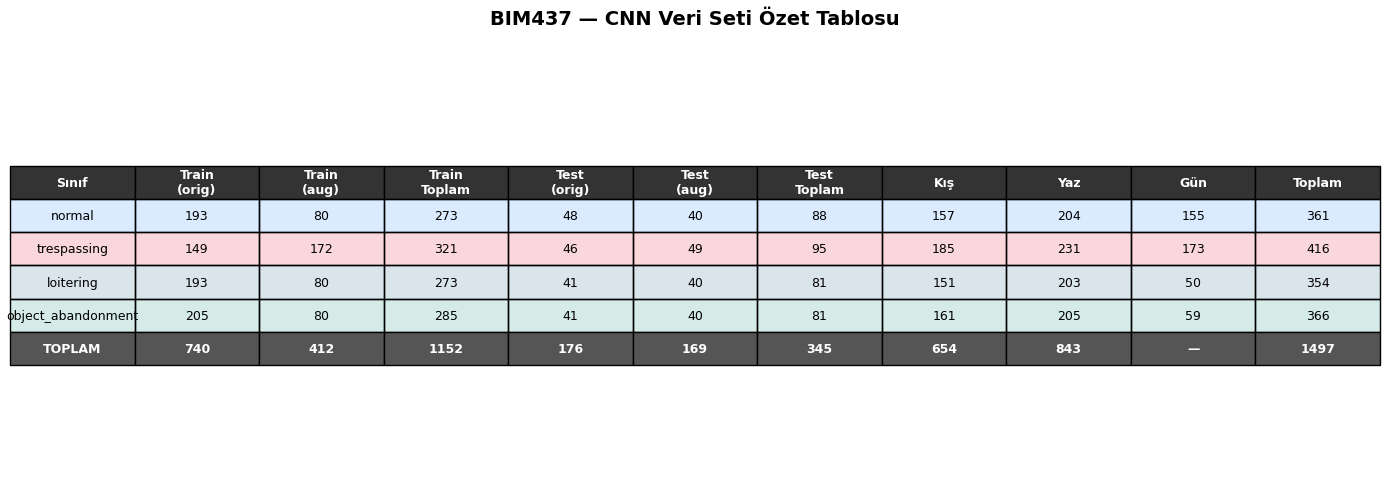

✓ 01_summary_table.png


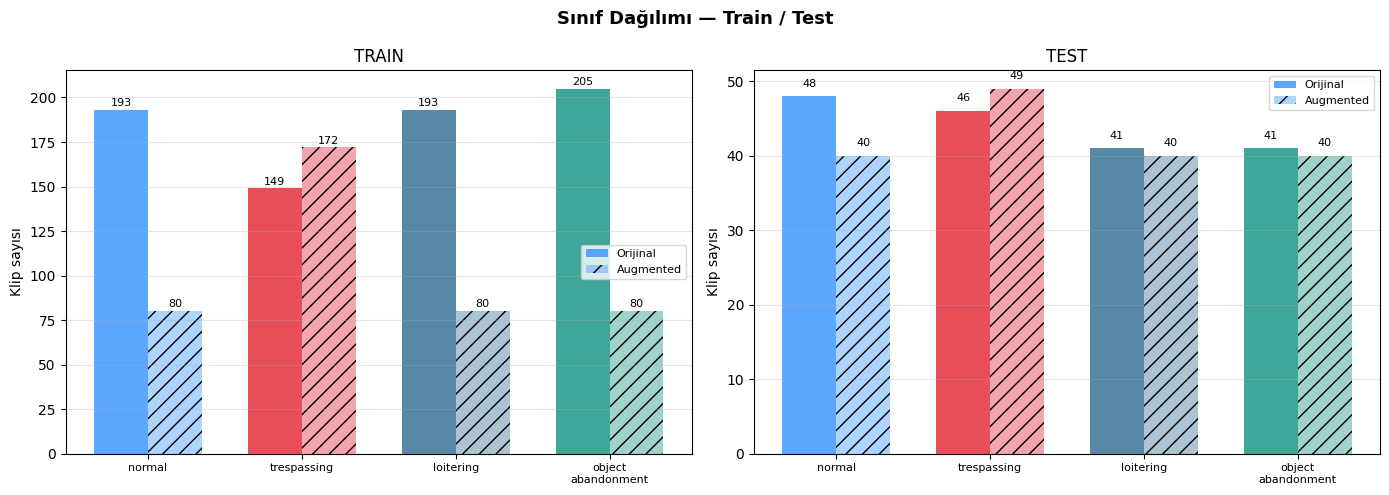

✓ 02_class_distribution.png


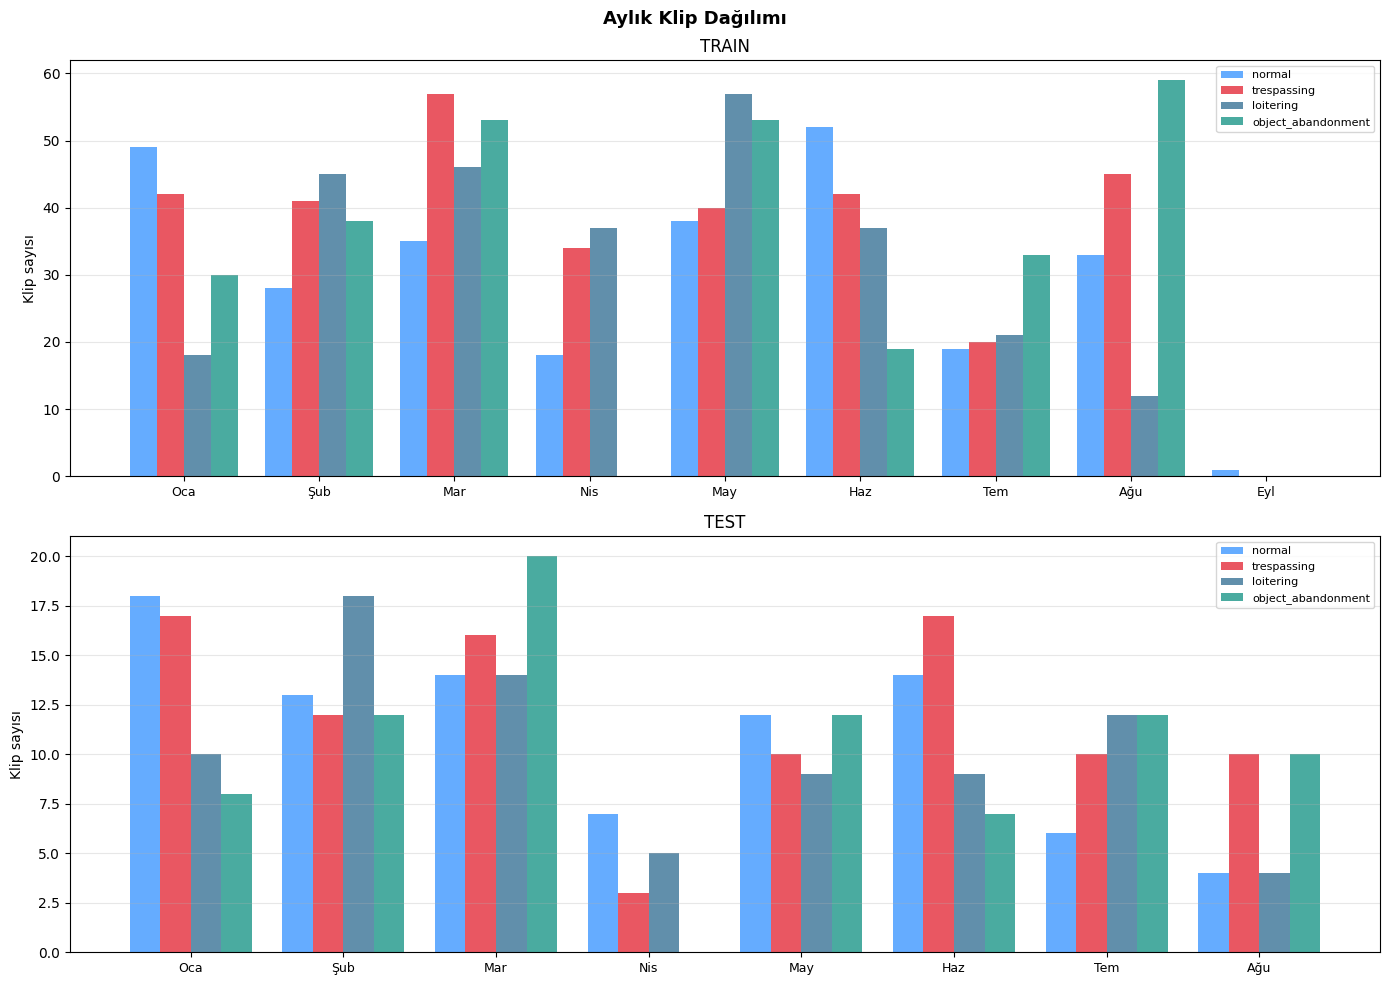

✓ 03_monthly_distribution.png


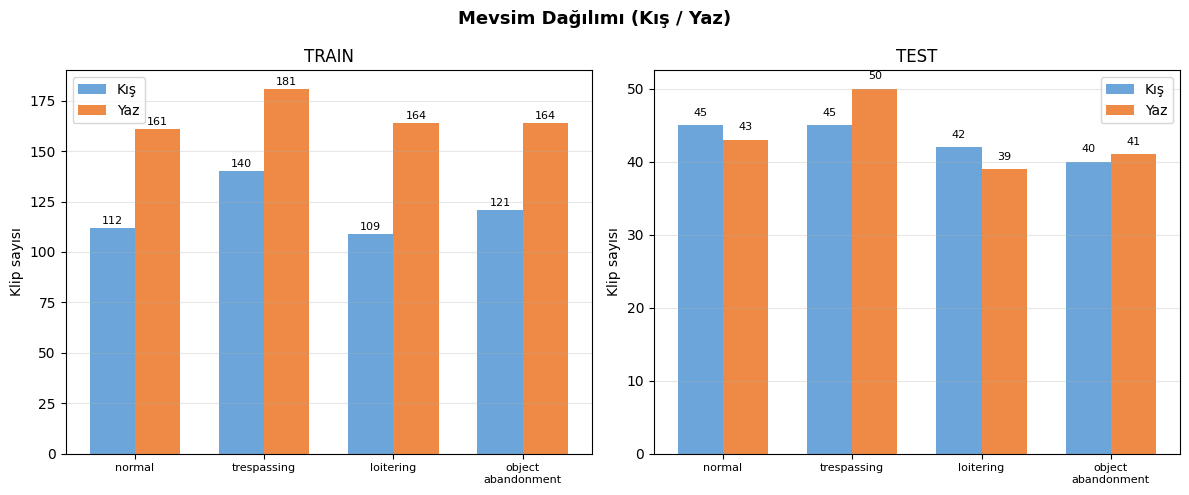

✓ 04_season_distribution.png


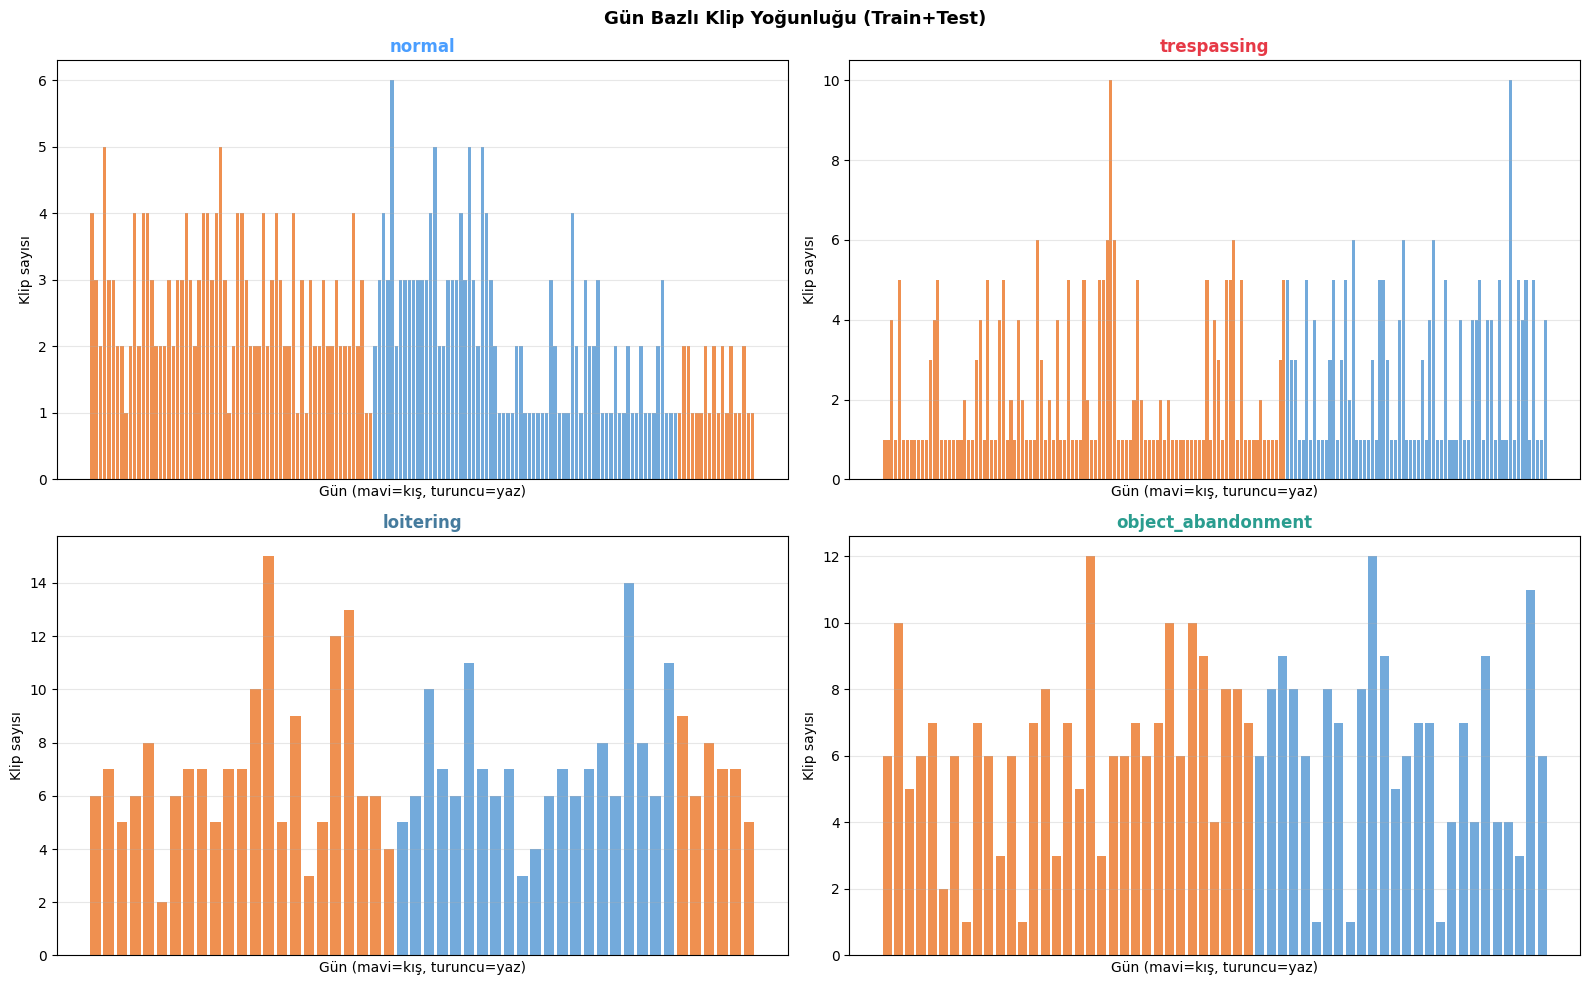

✓ 05_day_density.png

  RAPOR TAMAMLANDI
  Toplam PNG : 5
  Locale     : /content/cnn_dataset_report
  Drive      : /content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/cnn_dataset_report

  * işaretliler augmented kliplerdir


In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import defaultdict
from tqdm import tqdm
import shutil

LOCAL_FINAL = Path("/content/training_final")
DRIVE_OUT   = Path("/content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/training_final")
REPORT_DIR  = Path("/content/cnn_dataset_report")
REPORT_DRIVE = DRIVE_OUT.parent / "cnn_dataset_report"

# ── Eski PNG'leri sil ─────────────────────────────────────────────────────────
print("Eski PNG'ler siliniyor...")
deleted = 0
for d in [REPORT_DIR, REPORT_DRIVE]:
    if d.exists():
        for f in d.glob("*.png"):
            f.unlink()
            deleted += 1
print(f"✓ {deleted} PNG silindi")

REPORT_DIR.mkdir(exist_ok=True)
REPORT_DRIVE.mkdir(exist_ok=True)

CLASSES = ["normal","trespassing","loitering","object_abandonment"]
MONTH_NAMES = {1:"Oca",2:"Şub",3:"Mar",4:"Nis",5:"May",6:"Haz",
               7:"Tem",8:"Ağu",9:"Eyl",10:"Eki",11:"Kas",12:"Ara"}
CLS_COLORS = {
    "normal":             "#4a9eff",
    "trespassing":        "#E63946",
    "loitering":          "#457B9D",
    "object_abandonment": "#2A9D8F",
}
def is_winter(day): return 202101 <= int(day[:6]) <= 202103

# ── Drive'dan tara (güncel veri) ──────────────────────────────────────────────
print("\nDrive taranıyor...")
all_clips = []
stats     = defaultdict(lambda: defaultdict(lambda: {
    "orig":0,"aug":0,"frames":0,
    "months":defaultdict(int),
    "days":set(),
    "winter":0,"summer":0,
}))

for split in ["train","test"]:
    for cls in CLASSES:
        cls_dir = DRIVE_OUT / split / cls
        if not cls_dir.exists(): continue
        for day_dir in sorted(cls_dir.iterdir()):
            if not day_dir.is_dir(): continue
            for clip_dir in sorted(day_dir.iterdir()):
                if not clip_dir.is_dir(): continue
                frames = sorted(clip_dir.glob("*.jpg"))
                if not frames: continue
                is_aug  = clip_dir.name.startswith("aug_")
                season  = "KIŞ" if is_winter(day_dir.name) else "YAZ"
                month   = int(day_dir.name[4:6])
                s       = stats[split][cls]
                if is_aug: s["aug"]  += 1
                else:      s["orig"] += 1
                s["frames"]          += len(frames)
                s["months"][month]   += 1
                s["days"].add(day_dir.name)
                if season=="KIŞ": s["winter"] += 1
                else:             s["summer"] += 1
                all_clips.append({
                    "split":    split,
                    "cls":      cls,
                    "day":      day_dir.name,
                    "clip_name":clip_dir.name,
                    "mid_frame":frames[len(frames)//2],
                    "is_aug":   is_aug,
                    "season":   season,
                    "month":    month,
                })

print(f"Toplam klip: {len(all_clips)}")

def save_png(fig, name):
    """Locale + Drive'a kaydet."""
    for d in [REPORT_DIR, REPORT_DRIVE]:
        fig.savefig(str(d/name), dpi=150, bbox_inches='tight')

# ── PNG 1: Ana özet tablo ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14,5))
ax.axis('off')
table_data = [["Sınıf","Train\n(orig)","Train\n(aug)","Train\nToplam",
               "Test\n(orig)","Test\n(aug)","Test\nToplam",
               "Kış","Yaz","Gün","Toplam"]]
grand = defaultdict(int)
for cls in CLASSES:
    tr_o = stats["train"][cls]["orig"]
    tr_a = stats["train"][cls]["aug"]
    te_o = stats["test"][cls]["orig"]
    te_a = stats["test"][cls]["aug"]
    w    = stats["train"][cls]["winter"]+stats["test"][cls]["winter"]
    s    = stats["train"][cls]["summer"]+stats["test"][cls]["summer"]
    d    = len(stats["train"][cls]["days"]|stats["test"][cls]["days"])
    tot  = tr_o+tr_a+te_o+te_a
    table_data.append([cls,str(tr_o),str(tr_a),str(tr_o+tr_a),
                       str(te_o),str(te_a),str(te_o+te_a),
                       str(w),str(s),str(d),str(tot)])
    for k,v in [("tr_o",tr_o),("tr_a",tr_a),("te_o",te_o),
                ("te_a",te_a),("w",w),("s",s),("tot",tot)]:
        grand[k]+=v
table_data.append(["TOPLAM",
                   str(grand["tr_o"]),str(grand["tr_a"]),
                   str(grand["tr_o"]+grand["tr_a"]),
                   str(grand["te_o"]),str(grand["te_a"]),
                   str(grand["te_o"]+grand["te_a"]),
                   str(grand["w"]),str(grand["s"]),"—",
                   str(grand["tot"])])
tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1,1.8)
for i,cls in enumerate(CLASSES):
    for j in range(len(table_data[0])):
        tbl[i+1,j].set_facecolor(CLS_COLORS[cls]+"33")
for j in range(len(table_data[0])):
    tbl[0,j].set_facecolor("#333333")
    tbl[0,j].set_text_props(color='white',fontweight='bold')
    tbl[len(CLASSES)+1,j].set_facecolor("#555555")
    tbl[len(CLASSES)+1,j].set_text_props(color='white',fontweight='bold')
ax.set_title("BIM437 — CNN Veri Seti Özet Tablosu",
             fontsize=14,fontweight='bold',pad=20)
plt.tight_layout()
save_png(fig,"01_summary_table.png")
plt.show(); plt.close()
print("✓ 01_summary_table.png")

# ── PNG 2: Sınıf dağılımı ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1,2,figsize=(14,5))
fig.suptitle("Sınıf Dağılımı — Train / Test",fontsize=13,fontweight='bold')
for ax,split in zip(axes,["train","test"]):
    orig_vals = [stats[split][c]["orig"] for c in CLASSES]
    aug_vals  = [stats[split][c]["aug"]  for c in CLASSES]
    x=np.arange(len(CLASSES)); w=0.35
    b1=ax.bar(x-w/2,orig_vals,w,label='Orijinal',
              color=[CLS_COLORS[c] for c in CLASSES],alpha=0.9)
    b2=ax.bar(x+w/2,aug_vals, w,label='Augmented',
              color=[CLS_COLORS[c] for c in CLASSES],alpha=0.45,hatch='//')
    for bar in list(b1)+list(b2):
        h=bar.get_height()
        if h>0: ax.text(bar.get_x()+bar.get_width()/2,h+1,
                        str(int(h)),ha='center',va='bottom',fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace("_","\n") for c in CLASSES],fontsize=8)
    ax.set_title(split.upper()); ax.set_ylabel("Klip sayısı")
    ax.legend(fontsize=8); ax.grid(axis='y',alpha=0.3)
plt.tight_layout()
save_png(fig,"02_class_distribution.png")
plt.show(); plt.close()
print("✓ 02_class_distribution.png")

# ── PNG 3: Aylık dağılım ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2,1,figsize=(14,10))
fig.suptitle("Aylık Klip Dağılımı",fontsize=13,fontweight='bold')
for ax,split in zip(axes,["train","test"]):
    month_cls = defaultdict(lambda: defaultdict(int))
    for c in all_clips:
        if c["split"]==split:
            month_cls[c["month"]][c["cls"]] += 1
    months=sorted(month_cls.keys())
    x=np.arange(len(months)); w=0.2
    for i,cls in enumerate(CLASSES):
        vals=[month_cls[m][cls] for m in months]
        ax.bar(x+i*w,vals,w,label=cls,color=CLS_COLORS[cls],alpha=0.85)
    ax.set_xticks(x+w*1.5)
    ax.set_xticklabels([MONTH_NAMES[m] for m in months],fontsize=9)
    ax.set_title(split.upper()); ax.set_ylabel("Klip sayısı")
    ax.legend(fontsize=8); ax.grid(axis='y',alpha=0.3)
plt.tight_layout()
save_png(fig,"03_monthly_distribution.png")
plt.show(); plt.close()
print("✓ 03_monthly_distribution.png")

# ── PNG 4: Mevsim dağılımı ────────────────────────────────────────────────────
fig, axes = plt.subplots(1,2,figsize=(12,5))
fig.suptitle("Mevsim Dağılımı (Kış / Yaz)",fontsize=13,fontweight='bold')
for ax,split in zip(axes,["train","test"]):
    winter_vals=[stats[split][c]["winter"] for c in CLASSES]
    summer_vals=[stats[split][c]["summer"] for c in CLASSES]
    x=np.arange(len(CLASSES)); w=0.35
    ax.bar(x-w/2,winter_vals,w,label='Kış',color='#5b9bd5',alpha=0.9)
    ax.bar(x+w/2,summer_vals,w,label='Yaz',color='#ed7d31',alpha=0.9)
    for bars,vals in [(x-w/2,winter_vals),(x+w/2,summer_vals)]:
        for xi,v in zip(bars,vals):
            if v>0: ax.text(xi,v+1,str(v),ha='center',va='bottom',fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace("_","\n") for c in CLASSES],fontsize=8)
    ax.set_title(split.upper()); ax.set_ylabel("Klip sayısı")
    ax.legend(); ax.grid(axis='y',alpha=0.3)
plt.tight_layout()
save_png(fig,"04_season_distribution.png")
plt.show(); plt.close()
print("✓ 04_season_distribution.png")

# ── PNG 5: Gün yoğunluğu ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2,2,figsize=(16,10))
fig.suptitle("Gün Bazlı Klip Yoğunluğu (Train+Test)",
             fontsize=13,fontweight='bold')
for ax,cls in zip(axes.flat,CLASSES):
    day_cnt=defaultdict(int)
    for c in all_clips:
        if c["cls"]==cls: day_cnt[c["day"]]+=1
    days=sorted(day_cnt.keys())
    vals=[day_cnt[d] for d in days]
    colors=['#5b9bd5' if is_winter(d) else '#ed7d31' for d in days]
    ax.bar(range(len(days)),vals,color=colors,alpha=0.85,width=0.8)
    ax.set_title(cls,color=CLS_COLORS[cls],fontweight='bold')
    ax.set_xlabel("Gün (mavi=kış, turuncu=yaz)")
    ax.set_ylabel("Klip sayısı")
    ax.grid(axis='y',alpha=0.3); ax.set_xticks([])
plt.tight_layout()
save_png(fig,"05_day_density.png")
plt.show(); plt.close()
print("✓ 05_day_density.png")


# ── Özet ─────────────────────────────────────────────────────────────────────
all_pngs = list(REPORT_DIR.glob("*.png"))
print(f"\n{'='*55}")
print(f"  RAPOR TAMAMLANDI")
print(f"{'='*55}")
print(f"  Toplam PNG : {len(all_pngs)}")
print(f"  Locale     : {REPORT_DIR}")
print(f"  Drive      : {REPORT_DRIVE}")
print("\n  * işaretliler augmented kliplerdir")

In [31]:
from pathlib import Path

DRIVE_OUT = Path("/content/drive/MyDrive/archive/Data_Annotated_Subset_Object_Detectors/training_final")

print("── Drive Trespassing Doğrulama ─────────────────────────")
for split in ["train","test"]:
    tres = DRIVE_OUT / split / "trespassing"
    print(f"\n[{split.upper()}/trespassing]")
    print(f"  Klasör var mı: {tres.exists()}")
    if not tres.exists(): continue

    # Kaç gün klasörü var
    days = [d for d in tres.iterdir() if d.is_dir()]
    print(f"  Gün klasörü  : {len(days)}")

    # Kaç klip klasörü var
    clips = [c for d in days for c in d.iterdir() if c.is_dir()]
    print(f"  Klip klasörü : {len(clips)}")

    # Kaç jpg var
    jpgs = list(tres.rglob("*.jpg"))
    print(f"  JPG sayısı   : {len(jpgs)}")

    # frame_001 sayısı = klip sayısı
    frame1 = list(tres.rglob("frame_001.jpg"))
    print(f"  frame_001    : {len(frame1)}  ← gerçek klip sayısı")

    # İlk 3 günü göster
    print(f"  İlk 3 gün:")
    for d in sorted(days)[:3]:
        n = len([c for c in d.iterdir() if c.is_dir()])
        print(f"    {d.name}: {n} klip")

── Drive Trespassing Doğrulama ─────────────────────────

[TRAIN/trespassing]
  Klasör var mı: True
  Gün klasörü  : 160
  Klip klasörü : 321
  JPG sayısı   : 4871
  frame_001    : 321  ← gerçek klip sayısı
  İlk 3 gün:
    20200402: 1 klip
    20200404: 1 klip
    20200406: 4 klip

[TEST/trespassing]
  Klasör var mı: True
  Gün klasörü  : 39
  Klip klasörü : 95
  JPG sayısı   : 1520
  frame_001    : 95  ← gerçek klip sayısı
  İlk 3 gün:
    20200409: 1 klip
    20200416: 1 klip
    20200417: 1 klip
